# Part 2

## Imports

In [2]:
import math
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import scipy.stats as stats
import scipy

## Task 7

## Task 7

In [2]:
Q = np.array([[-0.0085,0.005,0.0025,0,0.001],
                  [0,-0.014,0.005,0.004,0.005],
                  [0,0,-0.008,0.003,0.005],
                  [0,0,0,-0.009,0.009],
                  [0,0,0,0,0]])

N,_ = Q.shape

states = np.arange(1,N+1)

In [5]:
def contMarkov(Q):
    t = 0
    s = 1
    track = [(0,1)]
    while s != 5:
        t_sojourn = np.random.exponential(scale = 1/-Q[s-1][s-1])
        t += t_sojourn
        
        s_pos = np.delete(states,s-1)

        probs = []
        for x in s_pos:
            probs.append(-Q[s-1][x-1]/Q[s-1][s-1])

        s_next = int(np.random.choice(s_pos, p=probs))
        s = s_next

        track.append((t, s))

    return t,track

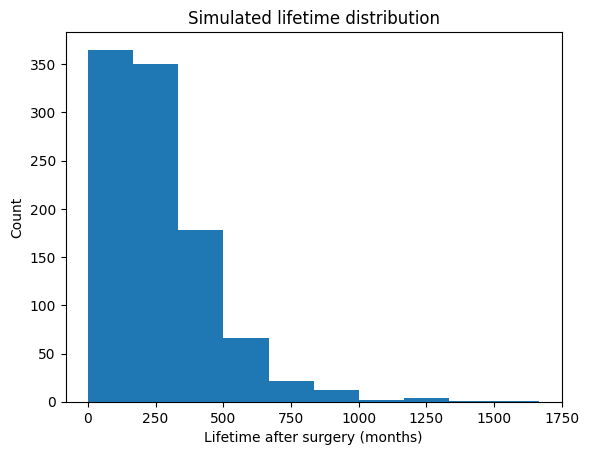

In [6]:
n_women = 1000

results = [contMarkov(Q) for i in range(n_women)]

lifetimes = np.array([t for t,track in results])
trackings = [track for t,track in results]

plt.hist(lifetimes)
plt.xlabel("Lifetime after surgery (months)")
plt.ylabel("Count")
plt.title("Simulated lifetime distribution")
plt.show()

In [16]:
lifetime_mean = np.mean(lifetimes)
lifetime_std = np.std(lifetimes,ddof=1)

alpha=0.05
p_quantile_1 = stats.t.ppf(q=alpha/2,df=n_women-1)
p_quantile_2 = stats.t.ppf(q=1-alpha/2,df=n_women-1)

CI_mean = [float(lifetime_mean + (lifetime_std/np.sqrt(n_women))*p_quantile_1),float(lifetime_mean + (lifetime_std/np.sqrt(n_women))*p_quantile_2)]

chi2_lower = stats.chi2.ppf(alpha/2, df=n_women-1)
chi2_upper = stats.chi2.ppf(1-alpha/2, df=n_women-1)

CI_std = [float(np.sqrt((n_women-1)*lifetime_std**2 / chi2_upper)), float(np.sqrt((n_women-1)*lifetime_std**2 / chi2_lower))]


print(lifetime_mean,CI_mean)
print(lifetime_std,CI_std)


264.6963233857765 [252.08182046623705, 277.31082630531597]
203.28042579066565 [194.7451582428789, 212.60395517145824]


In [8]:
t_distReap = 30.5

n_distReap = sum(any(state in [3,4] and time <= t_distReap for time, state in tracking) for tracking in trackings)

prop_distReap = n_distReap / n_women

print(prop_distReap)

0.085


## Task 8

In [9]:
Q_s = np.array([[-0.0085,0.005,0.0025,0],
                  [0,-0.014,0.005,0.004],
                  [0,0,-0.008,0.003],
                  [0,0,0,-0.009]])

p_0 = np.array([1,0,0,0])

ones = np.array([1,1,1,1])

In [10]:
def F_T(t):
    return 1 - p_0 @ scipy.linalg.expm(Q_s*t) @ ones

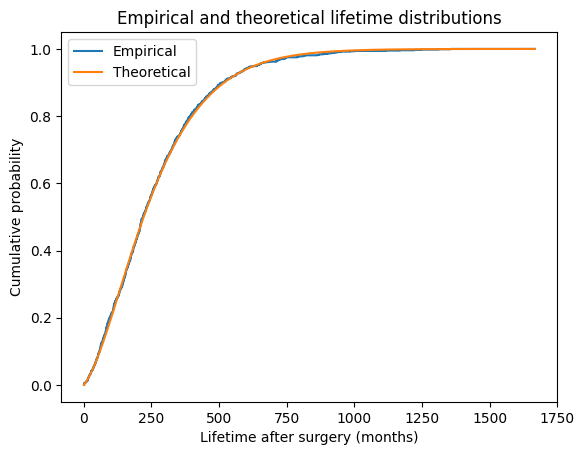

0.016698139144578017


In [17]:
T = np.linspace(0,max(lifetimes),n_women)
theory = np.array([F_T(t) for t in T])

#Manual:
lifetime_sorted = np.sort(lifetimes)
empiry = np.arange(1, n_women+1) / n_women

plt.step(lifetime_sorted,empiry, label="Empirical")
plt.plot(T, theory, label="Theoretical")
plt.legend()
plt.xlabel("Lifetime after surgery (months)")
plt.ylabel("Cumulative probability")
plt.title("Empirical and theoretical lifetime distributions")
plt.show()

#Alternative:
#ecdf = stats.ecdf(lifetimes)

#plt.step(ecdf.cdf.quantiles,ecdf.cdf.probabilities, label="Empirical")
#plt.plot(T, theory, label="Theoretical")
#plt.legend()
#plt.show()


#KS-test:
#stats.kstest(lifetimes,F_T)

KS = stats.kstest(lifetimes,lambda t: np.array([F_T(x) for x in np.atleast_1d(t)]))
D = KS.statistic

print(D)

## Task 9

### Defining parameters

In [15]:
n_women = 1000

Q = np.array([
    [-0.0085, 0.005,  0.0025, 0.000, 0.001],
    [ 0.0000,-0.014,  0.0050, 0.004, 0.005],
    [ 0.0000, 0.000, -0.0080, 0.003, 0.005],
    [ 0.0000, 0.000,  0.0000,-0.009, 0.009],
    [ 0.0000, 0.000,  0.0000, 0.000, 0.000]
])

Q_treatment = np.array([
    [-0.00475, 0.0025, 0.00125, 0.000, 0.001],
    [ 0.00000,-0.0070, 0.00000, 0.002, 0.005],
    [ 0.00000, 0.0000,-0.00800, 0.003, 0.005],
    [ 0.00000, 0.0000, 0.00000,-0.009, 0.009],
    [ 0.00000, 0.0000, 0.00000, 0.000, 0.000]
])

def simulate_one_woman_ctmc(Q):
    current_state = 1
    time = 0.0
    path = [(time, current_state)]

    while current_state != 5:
        row = Q[current_state - 1]

        rate = -row[current_state - 1]

        waiting_time = np.random.exponential(scale= 1/rate)
        time += waiting_time

        jump_rates = row.copy()
        jump_rates[current_state - 1] = 0

        probabilities = jump_rates / rate

        next_state = np.random.choice(np.array([1, 2, 3, 4, 5]),p=probabilities)

        current_state = next_state
        path.append((time, current_state))

    return time, path

lifetimes_ctmc = []
paths_ctmc = []

for _ in range(n_women):
    lifetime, path = simulate_one_woman_ctmc(Q)
    lifetimes_ctmc.append(lifetime)
    paths_ctmc.append(path)

lifetimes_ctmc = np.array(lifetimes_ctmc)

In [16]:
def death(t, paths):
    death_count = 0

    for path in paths:
        is_dead = False

        for time, state in path:
            if time < t and state == 5:
                is_dead = True
                break

        if is_dead:
            death_count += 1

    return death_count


def kaplan_meier(t, paths):
    N = len(paths)
    return (N - death(t, paths)) / N





In [17]:



lifetimes_treatment = []
paths_treatment = []

for _ in range(n_women):
    lifetime, path = simulate_one_woman_ctmc(Q_treatment)
    lifetimes_treatment.append(lifetime)
    paths_treatment.append(path)

lifetimes_treatment = np.array(lifetimes_treatment)

death(230, paths_treatment)

376

In [18]:
max_time = max(np.max(lifetimes_ctmc), np.max(lifetimes_treatment))
times = np.linspace(0, max_time, 500)

S_no_treatment = np.array([kaplan_meier(t, paths_ctmc)for t in times])

S_treatment = np.array([kaplan_meier(t, paths_treatment)for t in times])

### Plot

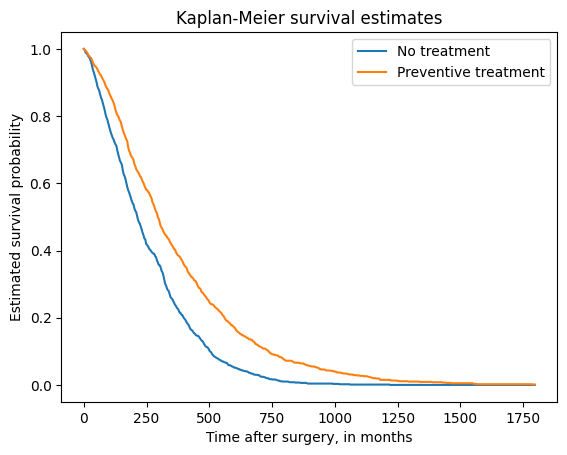

In [233]:
plt.plot(times, S_no_treatment, label="No treatment")
plt.plot(times, S_treatment, label="Preventive treatment")

plt.xlabel("Time after surgery, in months")
plt.ylabel("Estimated survival probability")
plt.title("Kaplan-Meier survival estimates")
plt.legend()
plt.show()

## Task 10

### Log rank test

In [ ]:
def log_rank_test(lifetimes_1, lifetimes_2):

    lifetimes_1 = np.array(lifetimes_1)
    lifetimes_2 = np.array(lifetimes_2)

    # All unique death times
    event_times = np.sort(np.unique(np.concatenate([lifetimes_1, lifetimes_2])))

    O1_total = 0
    E1_total = 0
    V1_total = 0

    n1 = len(lifetimes_1)
    n2 = len(lifetimes_2)

    for t in event_times:
        # Number at risk just before time t
        Y1 = np.sum(lifetimes_1 >= t)
        Y2 = np.sum(lifetimes_2 >= t)
        Y = Y1 + Y2

        # Number of deaths at time t
        d1 = np.sum(lifetimes_1 == t)
        d2 = np.sum(lifetimes_2 == t)
        d = d1 + d2

        if Y <= 1:
            continue

        # Observed deaths in group 1
        O1_total += d1

        # Expected deaths in group 1 under equal survival functions
        E1_total += d * (Y1 / Y)

        # Variance contribution
        V1_total += ((Y1 * Y2 * d * (Y - d)) /(Y**2 * (Y - 1)))

    test_statistic = (O1_total - E1_total)**2 / V1_total

    #if i use cdf i get p = 0 in the final result so use sf instead
    p_value = stats.chi2.sf(test_statistic, df=1)

    return test_statistic, p_value

In [20]:
test_statistic, p_value = log_rank_test(lifetimes_ctmc, lifetimes_treatment)

print("Log-rank test statistic:", test_statistic)
print("p-value:", p_value)


Log-rank test statistic: 69.9045940007264
p-value: 6.224331816587665e-17
